## Generating some mock data for Monolix

Consider logistic growth with growth rate $r_s$, carrying capacity $K$,
and initial value $S_0$:

\begin{align*}
\frac{dS}{dt} &= r_s S \left( 1 - \frac{S}{K} \right) \\
S(0) &= S_0
\end{align*}

Let $f(t, \Theta)$ represent the value of $S(t)$ given parameters $\Theta = \{ r_s, K, S_0 \}$.
We will simulate nonlinear mixed-effects modeling as follows:
- Choose population parameters $r_s^{pop}$, $K^{pop}$, $S_0^{pop}$,
standard deviations $\omega_{r_s}$, $\omega_K$, and $\omega_{S_0}$,
and a parameter $a$ for magnitude of observation noise.
- For each parameter $\theta \in \{ r_s, K, S_0 \}$
and each individual $i$, sample $\eta_\theta^{(i)}$ from $\mathcal{N}(0, \omega_\theta)$
and set the individual parameter $\theta^{(i)} = \theta^{pop} + \eta_\theta^{(i)}$.
Let $\Theta^{(i)} = \{ r_s^{(i)}, K^{(i)}, S_0^{pop} \}$.
- For each individual $i$, choose a set of observation times $t_{ij}$, and set
$y_{ij} = f(t_{ij}, \Theta^{(i)}) + a \varepsilon_{ij}$ where $\varepsilon_{ij} \sim \mathcal{N}(0, 1)$.

In [1]:
import random
from typing import Callable, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import odeint

### 1-variable case with an arbitrary number of parameters

In [2]:
def get_n_indiv_params(
    n: int, pop_params: list[float], pop_stds: list[float], seed=42
) -> list[list[float]]:
    """
    Given a list of population parameters (`pop_params`) and standard deviations (`pop_stds`),
    return a list of n lists of sampled parameters.
    """
    random.seed(seed)
    ret = [[] for _ in range(n)]
    for param, std in zip(pop_params, pop_stds):
        for indiv_param_list in ret:
            indiv_param_list.append(param + random.gauss(mu=0, sigma=std))
    return ret


def get_observations(
    indiv_params: list[list[float]],
    indiv_obs_times: list[list[float]],
    indiv_init_conditions: list[float],
    model: Callable[[float, float, list[float]], Iterable[float]],
    a: float,
    seed=42,
) -> list[list[float]]:
    """
    Given a list of individual parameter lists (`indiv_params`),
    a list of sorted lists of individual observation times (`indiv_obs_times`),
    a list of initial conditions for the ODE (`indiv_init_conditions`),
    an ODE function `model` mapping
        observation, time, and params to a 1-element iterable with its derivative,
    and an observation noise parameter `a`, return a list of lists of
    (noisy) observations.
    """
    random.seed(seed)
    ret = []
    for obs_time_list, param_list, init_condition in zip(
        indiv_obs_times, indiv_params, indiv_init_conditions
    ):
        obs_no_noise = odeint(model, init_condition, obs_time_list, args=(param_list,))
        ret.append([float(obs[0]) + a * random.gauss() for obs in obs_no_noise])
    return ret


def get_csv(
    indiv_obs_times: list[list[float]], obs: list[list[float]], seed: int
) -> pd.DataFrame:
    data = {"ID": [], "time": [], "y": []}
    for i, (t, y) in enumerate(zip(indiv_obs_times, obs)):
        data["ID"] += [i] * len(t)
        data["time"] += t
        data["y"] += y
    df = pd.DataFrame(data)
    df.to_csv(f"logistic{len(indiv_obs_times)}_{seed}.csv", index=False)
    return df

### logistic regression model and sample population parameters and stds

In [3]:
def model_logistic(y: float, t: float, params: list[int]):
    """
    `params` should be [rs, K, S0]
    """
    if len(params) != 3:
        raise ValueError(f"Expected 3 parameters in `params` but got {len(params)}")
    
    rs, K, _ = params
    return rs * y * (1 - y / K)

POP_PARAMS_LOGISTIC = [0.15, 700., 15.]
POP_STDS_LOGISTIC = [0.03, 35., 1.8]
A_LOGISTIC = 30


In [4]:
n = 50
seed = 42
indiv_params = get_n_indiv_params(n, POP_PARAMS_LOGISTIC, POP_STDS_LOGISTIC, seed=seed)
indiv_obs_times = [range(i % 10, 120 + i % 10, 10) for i in range(n)]
indiv_init_conditions = [params[-1] for params in indiv_params]
obs = get_observations(indiv_params, indiv_obs_times, indiv_init_conditions, model_logistic, A_LOGISTIC, seed=seed)

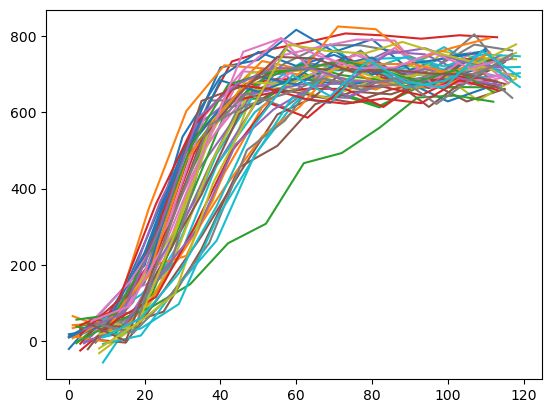

In [5]:
for i, (t, y) in enumerate(zip(indiv_obs_times, obs)):
    plt.plot(t, y, label=i)
# plt.legend()
plt.show()

In [6]:
get_csv(indiv_obs_times, obs, seed)

,ID,time,y
0,0,0,13.544799
1,0,10,65.425382
2,0,20,222.822245
3,0,30,485.683291
4,0,40,612.105275
...,...,...,...
595,49,79,736.103798
596,49,89,679.194796
597,49,99,664.174499
598,49,109,760.182312
